# BO Hyperparameter Correlation Analysis

Run `04_pareto_efficiency_analysis_v3.ipynb` first (it writes the per-run top-k CSVs and, in compare mode, `pooled_pareto_top_k.csv`).

Supports single- or multi-run configs. Default: v4 granular three-way compare (`configs/stage04/selection_notebooks_v4_granular.yaml`) — set `NB_CONFIG` in the setup cell to switch. Only numeric, non-constant hyperparameters are analyzed (e.g. `hdbscan__cluster_selection_method` is the constant `"eom"` in v4 and is excluded automatically).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

cwd = Path.cwd().resolve()
project_root = cwd
for _ in range(6):
    if (project_root / "configs").is_dir() and (project_root / "src").is_dir():
        break
    project_root = project_root.parent
else:
    raise RuntimeError("Could not find project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.common.config import load_config, resolve_path
from src.legacy.stage04_selection.pareto_analysis import analyze_hyperparameters
from src.stage04_eval_select.notebook_io import (
    STRATEGY_FILES,
    ensure_run_dirs,
    load_top_k_sets,
    resolve_comparison_dirs,
    resolve_run_dirs,
    resolve_runs,
)

# Notebook config: v4 granular three-way compare by default.
# For the legacy v3 L12-vs-L6 compare use configs/stage04/selection_notebooks.yaml.
NB_CONFIG = "configs/stage04/selection_notebooks_v4_granular.yaml"

nb_cfg = load_config(project_root / NB_CONFIG)
runs = resolve_runs(nb_cfg)
run_dirs = {run["run_id"]: resolve_run_dirs(run, project_root) for run in runs}
for dirs in run_dirs.values():
    ensure_run_dirs(dirs)
cmp_dirs = resolve_comparison_dirs(nb_cfg, project_root)
multi_run = len(runs) > 1

primary_run = runs[0]
figures_dir = run_dirs[primary_run["run_id"]]["figures_dir"]
tables_dir = run_dirs[primary_run["run_id"]]["tables_dir"]
top_models_dir = run_dirs[primary_run["run_id"]]["top_models_dir"]
HP_COLS = nb_cfg["hyperparameters"]
sns.set_style("whitegrid")
print(f"Runs: {[r['run_id'] for r in runs]} ({'compare' if multi_run else 'single'} mode)")

Runs: ['v4_l12_granular_phase1_dryrun', 'v4_l6_granular_phase1_dryrun', 'v4_mpnet_granular_phase1_dryrun'] (compare mode)


## 1. Load top-k sets

In [2]:
top_sets = load_top_k_sets(runs, project_root)
for (run_id, strategy), df in top_sets.items():
    label = df["model_label"].iloc[0] if len(df) else run_id
    print(f"{label} / {strategy}: {len(df)} trials")

# Keep only numeric, non-constant hyperparameters across all loaded top-k sets
# (e.g. hdbscan__cluster_selection_method is the constant string "eom" in v4).
all_top = pd.concat(top_sets.values(), ignore_index=True)
HP_NUMERIC = []
hp_dropped = {}
for col in HP_COLS:
    if col not in all_top.columns:
        hp_dropped[col] = "missing"
        continue
    numeric = pd.to_numeric(all_top[col], errors="coerce")
    if numeric.notna().sum() == 0:
        hp_dropped[col] = f"non-numeric (e.g. {all_top[col].dropna().iloc[0]!r})"
    elif numeric.nunique(dropna=True) <= 1:
        hp_dropped[col] = "constant"
    else:
        HP_NUMERIC.append(col)

print(f"\nHyperparameters analyzed ({len(HP_NUMERIC)}/{len(HP_COLS)}): {HP_NUMERIC}")
for col, reason in hp_dropped.items():
    print(f"  dropped {col}: {reason}")

v4_L12 / equal_weights: 10 trials
v4_L12 / coherence_priority: 10 trials
v4_L12 / eval_select: 10 trials
v4_L6 / equal_weights: 19 trials
v4_L6 / coherence_priority: 19 trials
v4_L6 / eval_select: 19 trials
v4_MPNet / equal_weights: 17 trials
v4_MPNet / coherence_priority: 17 trials
v4_MPNet / eval_select: 17 trials

Hyperparameters analyzed (7/8): ['bertopic__top_n_words', 'hdbscan__min_cluster_size', 'hdbscan__min_samples', 'umap__min_dist', 'umap__n_components', 'umap__n_neighbors', 'vectorizer__min_df']
  dropped hdbscan__cluster_selection_method: non-numeric (e.g. 'eom')


## 2. Correlation + Cohen's d

In [3]:
def metrics_for(name, df):
    if name == "eval_select":
        return [c for c in nb_cfg["performance_metrics_v3"] if c in df.columns]
    return [c for c in nb_cfg["performance_metrics_legacy"] if c in df.columns]

corr_parts = []
for (run_id, name), df in top_sets.items():
    corr = analyze_hyperparameters(df, HP_NUMERIC, metrics_for(name, df))
    corr["run_id"] = run_id
    corr["model_label"] = df["model_label"].iloc[0] if len(df) else run_id
    corr["strategy"] = name
    corr_parts.append(corr)
    path = run_dirs[run_id]["tables_dir"] / f"correlation_analysis_{name}.csv"
    corr.to_csv(path, index=False)
    print("Saved", path)

corr_all = pd.concat(corr_parts, ignore_index=True)
if cmp_dirs and multi_run:
    cmp_path = cmp_dirs["tables_dir"] / "correlation_analysis_all_runs.csv"
    corr_all.to_csv(cmp_path, index=False)
    print("Saved", cmp_path)

Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_l12_granular_phase1_dryrun/notebook_analysis/tables/correlation_analysis_equal_weights.csv
Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_l12_granular_phase1_dryrun/notebook_analysis/tables/correlation_analysis_coherence_priority.csv


Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_l12_granular_phase1_dryrun/notebook_analysis/tables/correlation_analysis_eval_select.csv


Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_l6_granular_phase1_dryrun/notebook_analysis/tables/correlation_analysis_equal_weights.csv
Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_l6_granular_phase1_dryrun/notebook_analysis/tables/correlation_analysis_coherence_priority.csv


Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_l6_granular_phase1_dryrun/notebook_analysis/tables/correlation_analysis_eval_select.csv
Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_mpnet_granular_phase1_dryrun/notebook_analysis/tables/correlation_analysis_equal_weights.csv
Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_mpnet_granular_phase1_dryrun/notebook_analysis/tables/correlation_analysis_coherence_priority.csv


Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_mpnet_granular_phase1_dryrun/notebook_analysis/tables/correlation_analysis_eval_select.csv
Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/_compare/v4_l12_l6_mpnet_pareto/tables/correlation_analysis_all_runs.csv


## 3. Boxplots

Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_l12_granular_phase1_dryrun/notebook_analysis/figures/hyperparameter_boxplots_all_strategies.png


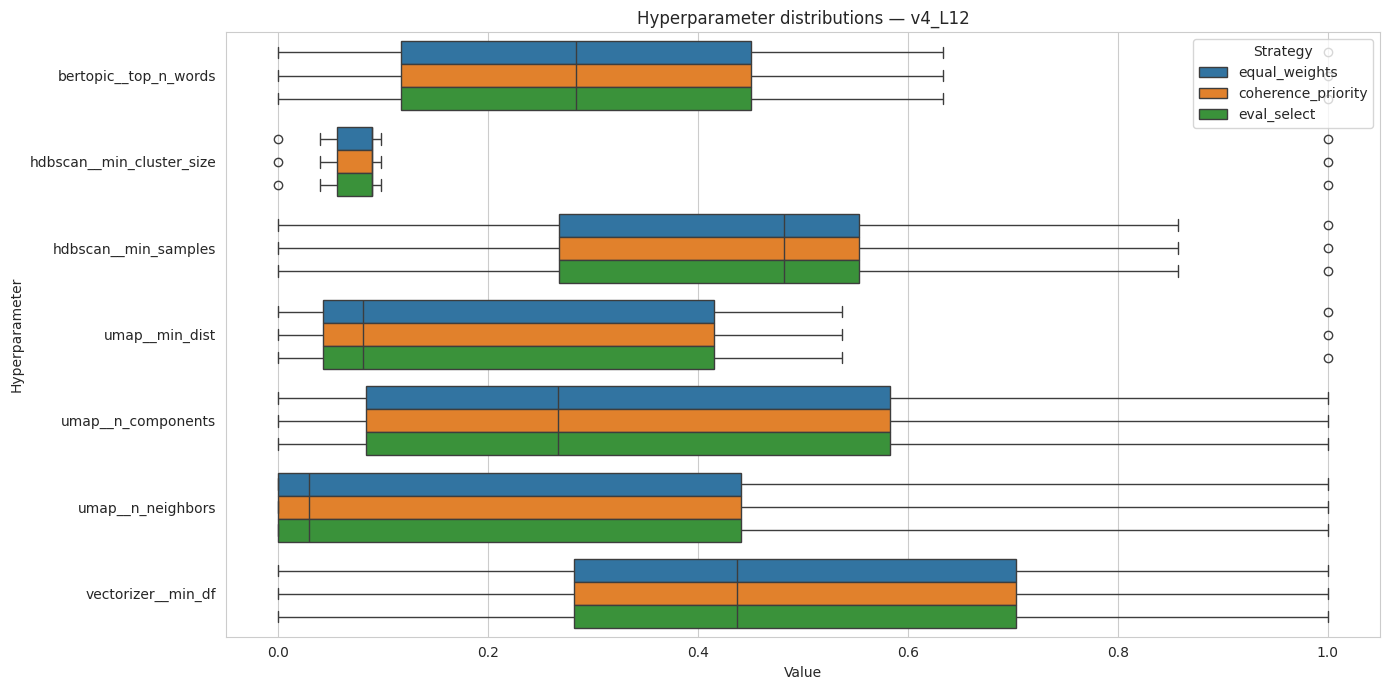

Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_l6_granular_phase1_dryrun/notebook_analysis/figures/hyperparameter_boxplots_all_strategies.png


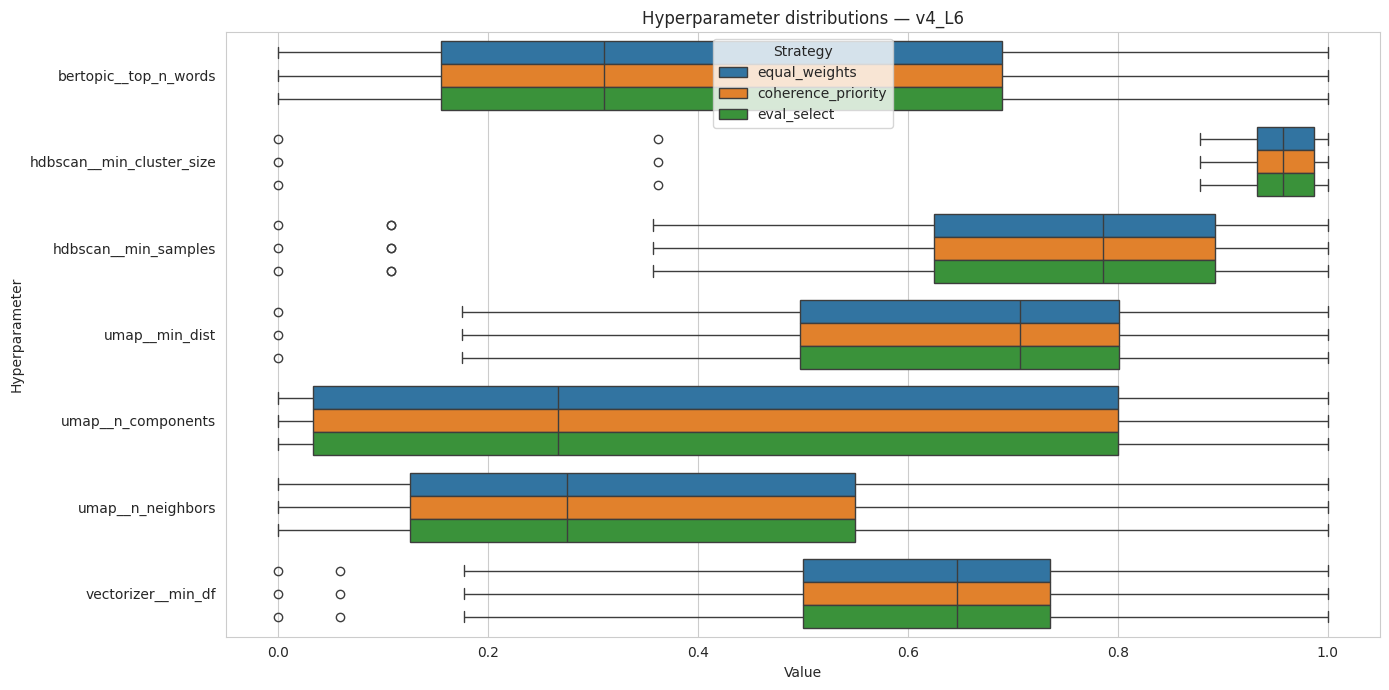

Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_mpnet_granular_phase1_dryrun/notebook_analysis/figures/hyperparameter_boxplots_all_strategies.png


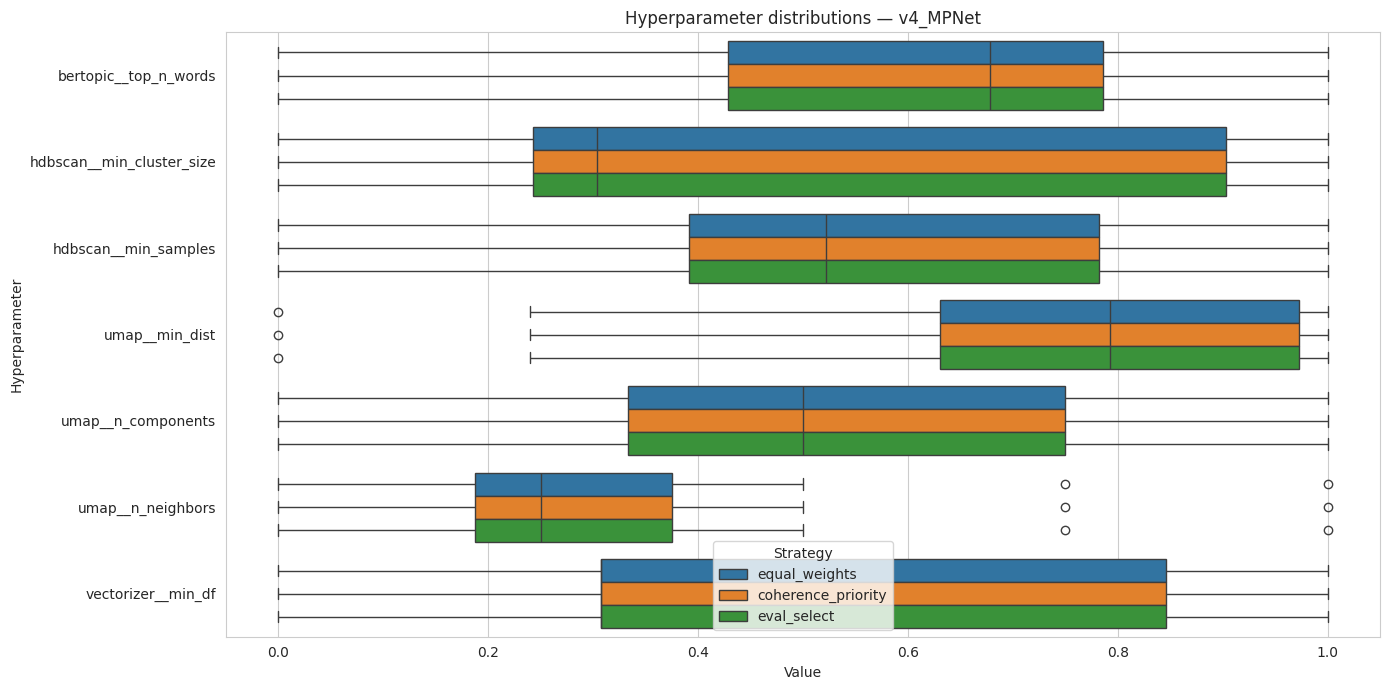

Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/_compare/v4_l12_l6_mpnet_pareto/figures/hyperparameter_boxplots_eval_select_by_run.png


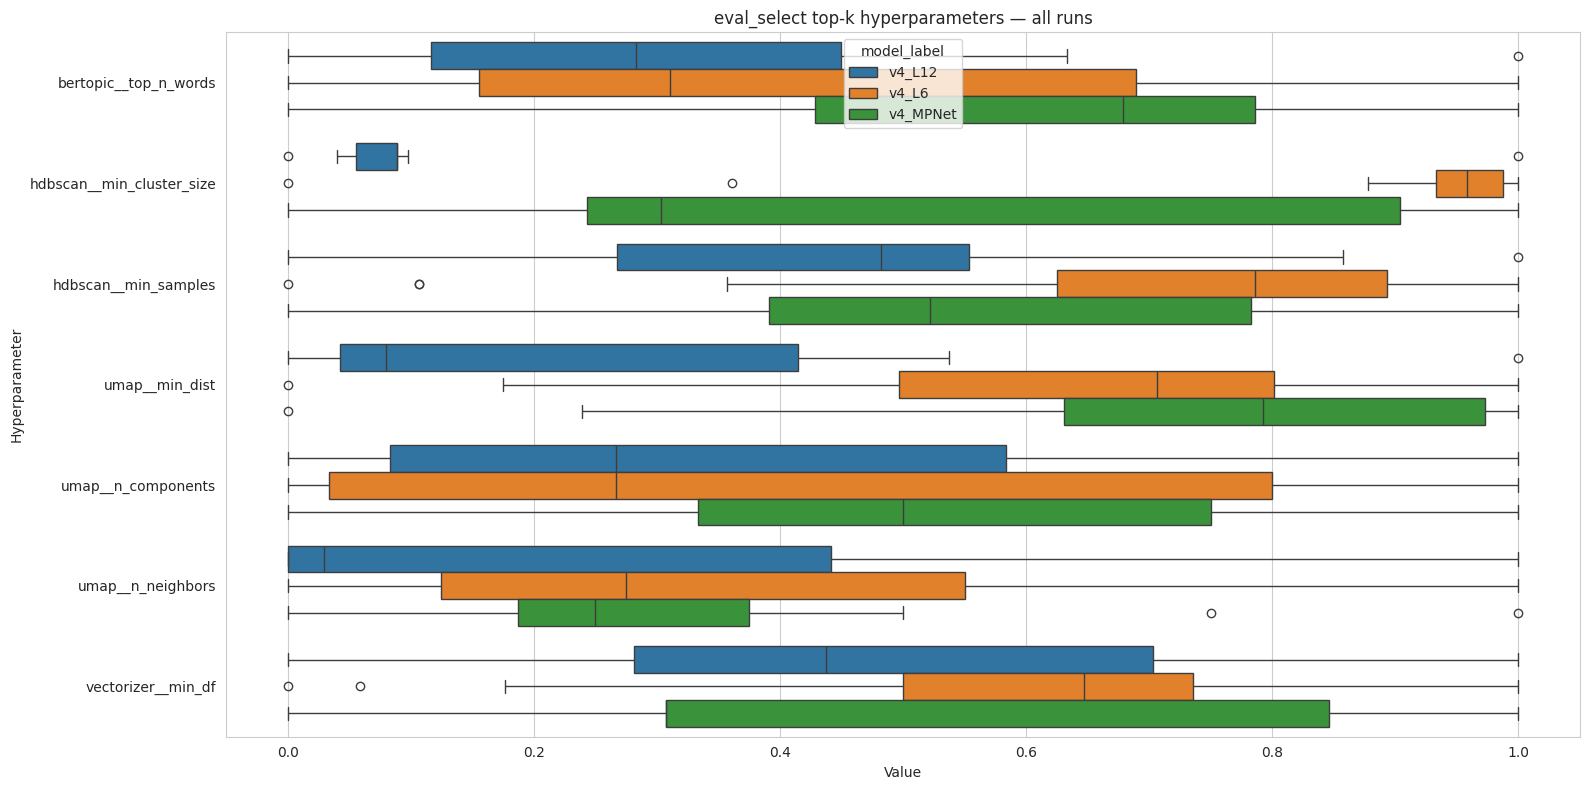

In [4]:
parts = []
for (run_id, name), df in top_sets.items():
    scaler = MinMaxScaler()
    norm = df.copy()
    norm[HP_NUMERIC] = scaler.fit_transform(df[HP_NUMERIC].astype(float))
    part = norm.melt(value_vars=HP_NUMERIC, var_name="Hyperparameter", value_name="Value")
    part["Strategy"] = name
    part["model_label"] = df["model_label"].iloc[0] if len(df) else run_id
    parts.append(part)
melted = pd.concat(parts, ignore_index=True)

for run in runs:
    rid = run["run_id"]
    label = run.get("label", rid)
    sub = melted[melted["model_label"] == label]
    fig, ax = plt.subplots(figsize=(14, 7))
    sns.boxplot(data=sub, x="Value", y="Hyperparameter", hue="Strategy", orient="h", ax=ax)
    ax.set_title(f"Hyperparameter distributions — {label}")
    plt.tight_layout()
    out = run_dirs[rid]["figures_dir"] / "hyperparameter_boxplots_all_strategies.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved {out}")
    plt.show()

if multi_run and cmp_dirs:
    fig, ax = plt.subplots(figsize=(16, 8))
    sns.boxplot(
        data=melted[melted["Strategy"] == "eval_select"],
        x="Value", y="Hyperparameter", hue="model_label", orient="h", ax=ax,
    )
    ax.set_title("eval_select top-k hyperparameters — all runs")
    plt.tight_layout()
    out = cmp_dirs["figures_dir"] / "hyperparameter_boxplots_eval_select_by_run.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved {out}")
    plt.show()

## 4. OLS + VIF (eval_select)

In [5]:
if HAS_STATSMODELS:
    ols_all = []
    for run in runs:
        rid = run["run_id"]
        label = run.get("label", rid)
        df_primary = top_sets[(rid, "eval_select")]
        X = df_primary[HP_NUMERIC].astype(float)
        X_const = sm.add_constant(X)
        ols_rows = []
        for metric in [c for c in ["coherence_c_v", "topic_diversity", "n_topics"] if c in df_primary.columns]:
            model = sm.OLS(df_primary[metric].astype(float), X_const).fit()
            for param in X_const.columns:
                row = {
                    "run_id": rid, "model_label": label, "metric": metric,
                    "parameter": param, "coef": model.params[param], "pvalue": model.pvalues[param],
                }
                ols_rows.append(row)
                ols_all.append(row)
            vif = pd.DataFrame([
                {"run_id": rid, "model_label": label, "metric": metric, "parameter": col,
                 "vif": variance_inflation_factor(X.values, i)}
                for i, col in enumerate(X.columns)
            ])
            vif.to_csv(run_dirs[rid]["tables_dir"] / f"vif_eval_select_{metric}.csv", index=False)
        pd.DataFrame(ols_rows).to_csv(run_dirs[rid]["tables_dir"] / "ols_eval_select.csv", index=False)
    if cmp_dirs and multi_run:
        pd.DataFrame(ols_all).to_csv(cmp_dirs["tables_dir"] / "ols_eval_select_all_runs.csv", index=False)
    print("Saved OLS/VIF per run")
else:
    print("statsmodels not installed")

Saved OLS/VIF per run


## 5. Random Forest importance

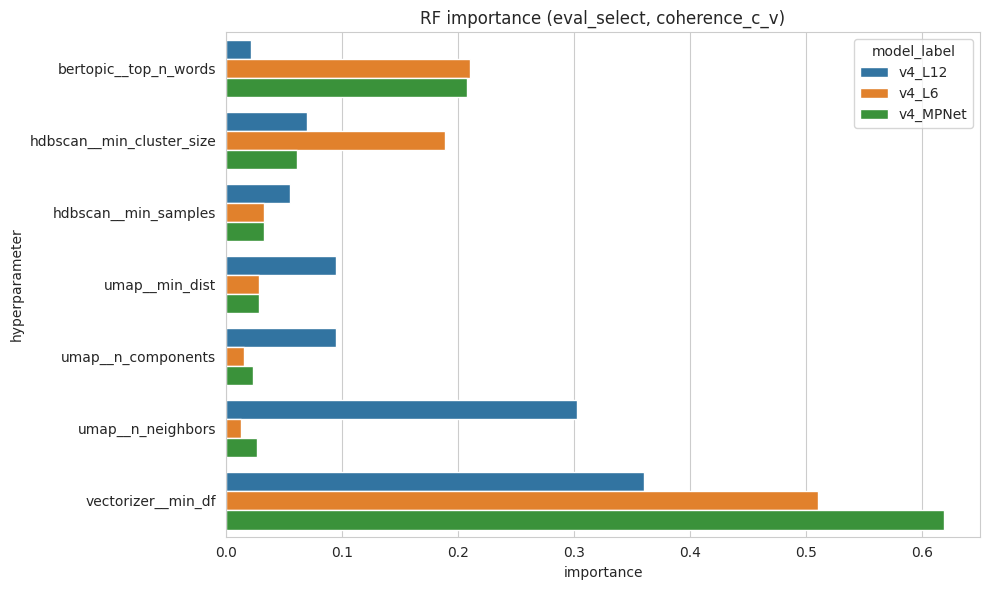

Saved random forest importance


In [6]:
rf_rows = []
for (run_id, name), df in top_sets.items():
    label = df["model_label"].iloc[0] if len(df) else run_id
    metrics = [c for c in ["coherence_c_v", "topic_diversity", "n_topics", "Combined_Score", "weighted_score"] if c in df.columns]
    X = df[HP_NUMERIC].astype(float)
    for metric in metrics:
        if len(df) < 3:
            continue
        rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X, df[metric].astype(float))
        for hp, imp in zip(HP_NUMERIC, rf.feature_importances_):
            rf_rows.append({
                "run_id": run_id, "model_label": label, "strategy": name,
                "metric": metric, "hyperparameter": hp, "importance": imp,
            })
rf_df = pd.DataFrame(rf_rows)
for run in runs:
    rid = run["run_id"]
    sub = rf_df[rf_df["run_id"] == rid]
    sub.to_csv(run_dirs[rid]["tables_dir"] / "random_forest_importance.csv", index=False)
if cmp_dirs and multi_run:
    rf_df.to_csv(cmp_dirs["tables_dir"] / "random_forest_importance_all_runs.csv", index=False)
    pivot = rf_df[rf_df["strategy"] == "eval_select"].pivot_table(
        index=["hyperparameter", "metric"], columns="model_label", values="importance"
    )
    pivot.to_csv(cmp_dirs["tables_dir"] / "random_forest_importance_eval_select_pivot.csv")
    fig, ax = plt.subplots(figsize=(10, 6))
    sub = rf_df[(rf_df["strategy"] == "eval_select") & (rf_df["metric"] == "coherence_c_v")]
    sns.barplot(data=sub, x="importance", y="hyperparameter", hue="model_label", orient="h", ax=ax)
    ax.set_title("RF importance (eval_select, coherence_c_v)")
    plt.tight_layout()
    plt.savefig(cmp_dirs["figures_dir"] / "random_forest_importance_coherence_by_run.png", dpi=150)
    plt.show()
print("Saved random forest importance")

## 6. XGBoost (optional)

In [7]:
if HAS_XGB:
    xgb_rows = []
    for run in runs:
        rid = run["run_id"]
        label = run.get("label", rid)
        df_primary = top_sets[(rid, "eval_select")]
        X = df_primary[HP_NUMERIC].astype(float)
        for metric in [c for c in ["coherence_c_v", "topic_diversity", "n_topics"] if c in df_primary.columns]:
            model = XGBRegressor(n_estimators=200, random_state=42, verbosity=0).fit(X, df_primary[metric].astype(float))
            for hp, imp in zip(HP_NUMERIC, model.feature_importances_):
                xgb_rows.append({"run_id": rid, "model_label": label, "metric": metric, "hyperparameter": hp, "importance": imp})
        pd.DataFrame([r for r in xgb_rows if r["run_id"] == rid]).to_csv(
            run_dirs[rid]["tables_dir"] / "xgboost_importance_eval_select.csv", index=False
        )
    if cmp_dirs and multi_run:
        pd.DataFrame(xgb_rows).to_csv(cmp_dirs["tables_dir"] / "xgboost_importance_eval_select_all_runs.csv", index=False)
    print("Saved XGBoost importance")
else:
    print("xgboost not installed")

xgboost not installed


## 7. Pooled cross-embedding analysis

Loads `pooled_pareto_top_k.csv` (global Pareto front across all embeddings, written by Notebook 1 section 10) and runs correlation + Random Forest importance on the pooled set, with the embedding one-hot encoded as a feature so its effect can be compared against the hyperparameters. Skipped when the file is missing or in single-run mode.

Pooled Pareto top-k: 30 trials from 3 embeddings
Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/_compare/v4_l12_l6_mpnet_pareto/tables/correlation_analysis_pooled_pareto.csv


,Hyperparameter,Metric,Correlation,p-value,Test_Type,Cohen_d
0,bertopic__top_n_words,coherence_c_v,0.249189,1.842011e-01,Pearson,-0.464714
1,bertopic__top_n_words,topic_diversity,-0.214525,2.549570e-01,Pearson,0.412676
2,bertopic__top_n_words,n_topics,-0.087566,6.454273e-01,Pearson,0.005004
3,bertopic__top_n_words,weighted_score,-0.153272,4.187277e-01,Pearson,0.274777
4,hdbscan__min_cluster_size,coherence_c_v,0.731030,4.475148e-06,Pearson,-1.239186
5,hdbscan__min_cluster_size,topic_diversity,-0.801774,1.006359e-07,Pearson,1.593576
6,hdbscan__min_cluster_size,n_topics,-0.968576,1.850240e-18,Pearson,2.291936
7,hdbscan__min_cluster_size,weighted_score,-0.818381,3.299720e-08,Pearson,1.753905
8,hdbscan__min_samples,coherence_c_v,0.544589,1.861683e-03,Pearson,-0.996969
9,hdbscan__min_samples,topic_diversity,-0.529136,2.642441e-03,Pearson,1.070123


Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/_compare/v4_l12_l6_mpnet_pareto/tables/random_forest_importance_pooled_pareto.csv


Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/_compare/v4_l12_l6_mpnet_pareto/figures/random_forest_importance_pooled_pareto.png


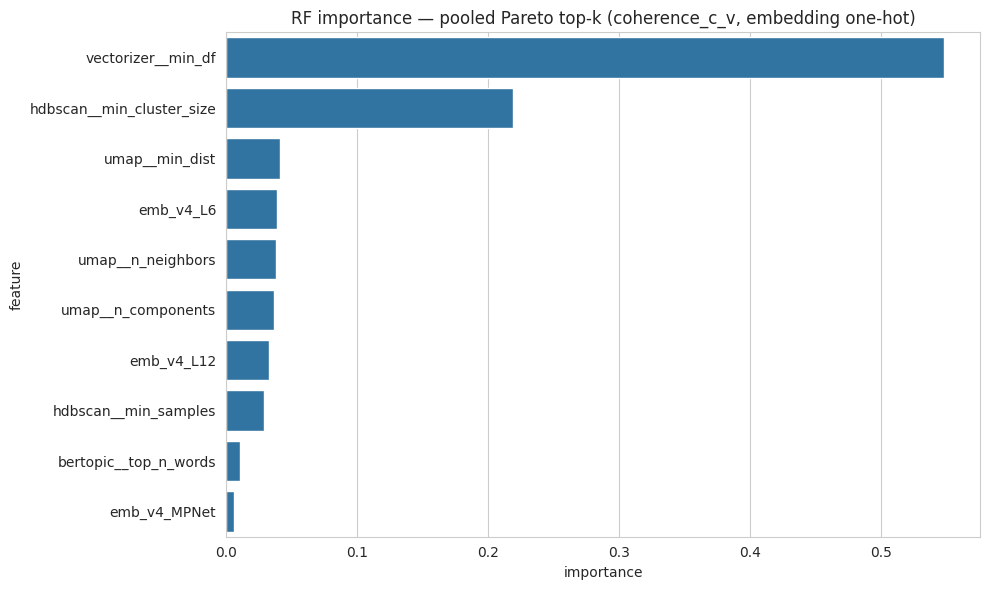

In [8]:
pooled_path = cmp_dirs["tables_dir"] / "pooled_pareto_top_k.csv" if cmp_dirs else None

if pooled_path is None or not pooled_path.exists():
    print(f"Pooled top-k not found ({pooled_path}): run Notebook 1 section 10 first.")
else:
    pooled = pd.read_csv(pooled_path)
    hp_pooled = [c for c in HP_NUMERIC if c in pooled.columns]
    pooled_metrics = [
        c for c in ["coherence_c_v", "topic_diversity", "n_topics", "weighted_score"] if c in pooled.columns
    ]
    print(f"Pooled Pareto top-k: {len(pooled)} trials from {pooled['model_label'].nunique()} embeddings")

    corr_pooled = analyze_hyperparameters(pooled, hp_pooled, pooled_metrics)
    corr_pooled_path = cmp_dirs["tables_dir"] / "correlation_analysis_pooled_pareto.csv"
    corr_pooled.to_csv(corr_pooled_path, index=False)
    print("Saved", corr_pooled_path)
    display(corr_pooled)

    # RF importance with the embedding as a one-hot feature next to the hyperparameters.
    emb_dummies = pd.get_dummies(pooled["model_label"], prefix="emb").astype(float)
    X_pooled = pd.concat([pooled[hp_pooled].astype(float), emb_dummies], axis=1)
    rf_pooled_rows = []
    for metric in pooled_metrics:
        if len(pooled) < 3:
            continue
        rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(
            X_pooled, pooled[metric].astype(float)
        )
        for feat, imp in zip(X_pooled.columns, rf.feature_importances_):
            rf_pooled_rows.append({"metric": metric, "feature": feat, "importance": imp})
    rf_pooled = pd.DataFrame(rf_pooled_rows)
    rf_pooled_path = cmp_dirs["tables_dir"] / "random_forest_importance_pooled_pareto.csv"
    rf_pooled.to_csv(rf_pooled_path, index=False)
    print("Saved", rf_pooled_path)

    if len(rf_pooled):
        fig, ax = plt.subplots(figsize=(10, 6))
        sub = rf_pooled[rf_pooled["metric"] == "coherence_c_v"].sort_values("importance", ascending=False)
        sns.barplot(data=sub, x="importance", y="feature", orient="h", ax=ax)
        ax.set_title("RF importance — pooled Pareto top-k (coherence_c_v, embedding one-hot)")
        plt.tight_layout()
        out = cmp_dirs["figures_dir"] / "random_forest_importance_pooled_pareto.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print("Saved", out)
        plt.show()